RSCl EZ054_240101 EZ054_240211
Total number of matched ROIs:  447 447
Long-to-Short mapping: session1=EZ054_240101 (Long), session2=EZ054_240211 (Short)
Total number of dual modulated cells:  45 45
Total number of short-only modulated cells:  42
Total number of long-only modulated cells:  56
RSCr EZ054_240102 EZ054_240212
Total number of matched ROIs:  607 607
Long-to-Short mapping: session1=EZ054_240102 (Long), session2=EZ054_240212 (Short)
Total number of dual modulated cells:  32 32
Total number of short-only modulated cells:  67
Total number of long-only modulated cells:  71
RSCl EZ055_240201 EZ055_240219
Total number of matched ROIs:  784 784
Long-to-Short mapping: session1=EZ055_240201 (Long), session2=EZ055_240219 (Short)
Total number of dual modulated cells:  111 111
Total number of short-only modulated cells:  122
Total number of long-only modulated cells:  93
RSCl EZ045_230824 EZ045_230915
Total number of matched ROIs:  597 597
Short-to-Long mapping: session1=EZ045_230824 (Sh

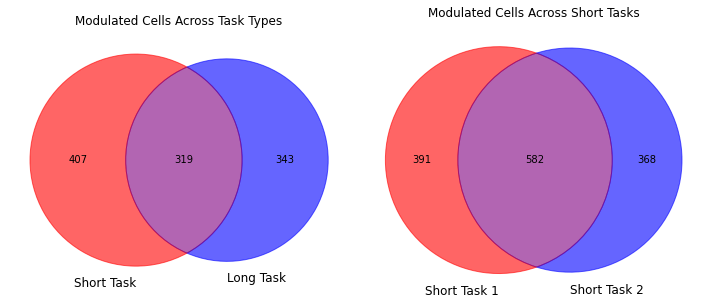


Total values for long-to-short and short-to-long conditions:
Short-only cells: 407
Long-only cells: 343
Dual modulated cells: 319

Total values for short-to-short conditions:
Short1-only cells: 391
Short2-only cells: 368
Dual modulated cells: 582

===== Fractions of Modulated Cells =====
1. Fraction of cells modulated by short task: 726/587.2 = 1.236 (123.6%)
2. Fraction of cells modulated by long task: 662/587.2 = 1.127 (112.7%)
3. Fraction of cells modulated by short task 1: 973/615.8 = 1.580 (158.0%)
4. Fraction of cells modulated by short task 2: 950/615.8 = 1.543 (154.3%)

===== Mixed Effect Model Analysis for Task Modulation =====

Raw p-values:
P-value for Short Task vs Long Task: 0.37398158181025365
P-value for Short Task vs Short Task 1: 0.09989090266294617
P-value for Short Task 1 vs Short Task 2: 0.5652425344951468

FDR-adjusted p-values:
Adjusted p-value for Short Task vs Long Task: 0.5609723727153805
Adjusted p-value for Short Task vs Short Task 1: 0.29967270798883855
Adj

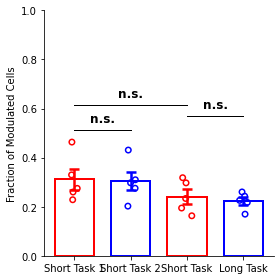


===== Overlap Fractions =====
1. Fraction of overlapping cells to total modulated cells (Short vs Long): 319/1069 = 0.298 (29.8%)
2. Fraction of overlapping cells to total modulated cells (Short1 vs Short2): 582/1341 = 0.434 (43.4%)


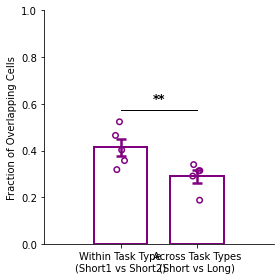

In [1]:
# Import necessary libraries
import sys
import glob
import os
from os.path import dirname, join as pjoin
# sys.path.append('C:\\jupyter_notebooks\\py_code')
sys.path.append('C:\\Users\\Eva\\Desktop\\ImagingCode')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pickle
import random
import xarray as xr
import pandas as pd
import h5py
import scipy.io as sio
# Load optimizers
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import minimize, basinhopping, curve_fit
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib_venn import venn2
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM

import BD_SciAdv as BD
plt_colors = BD.plt_color_dir()
save_dir = 'C:\\Users\\Eva\\Desktop\\Manuscript2025\\Figures\\4'

# Create save directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

def process_data(data_dir, data_dir2, n_back=15, is_long_to_short=None):
    os.chdir(data_dir)
    list_of_files = glob.glob('*.mat')
    
    total_ROI_list = []
    dual_modulated_list = []
    short_only_list = []
    long_only_list = []
    
    # If is_long_to_short is not provided, try to determine from the directory name
    if is_long_to_short is None:
        is_long_to_short = 'long_to_short' in data_dir
#         print(f"Automatically determined data type: {'Long-to-Short' if is_long_to_short else 'Short-to-Long'}")
    
    for file in list_of_files:
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        session1 = mouse + '_' + date1
        session2 = mouse + '_' + date2
        print(area, session1, session2)
        output_xarray1 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\across_task_matching','sse_{}_{}hist_updated.nc'.format(session1,n_back)))
        output_xarray2 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\across_task_matching','sse_{}_{}hist_updated.nc'.format(session2,n_back)))
        match_ss = pjoin(data_dir, '{}_{}_{}_{}.mat'.format(mouse,date1,date2,area))
        match_ss_contents = sio.loadmat(match_ss,squeeze_me=True)
        Mapping = match_ss_contents['roiMatchData']['allSessionMapping']
        ss1_mapped = Mapping.item()[:,0]-1
        ss2_mapped = Mapping.item()[:,1]-1
        
        out_pd1 = output_xarray1.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd1['tau_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).tau_RC 
        out_pd1['tau_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd1['crit_sig'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd1['crit_sig2'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05  #0.1
        out_pd1['crit_sig_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd1['crit_sig_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss1 = out_pd1.loc[ss1_mapped].reset_index()
        
            
        out_pd2 = output_xarray2.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd2['tau_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).tau_RC
        out_pd2['tau_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd2['crit_sig'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd2['crit_sig2'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05  #0.1
        out_pd2['crit_sig_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd2['crit_sig_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss2 = out_pd2.loc[ss2_mapped].reset_index()
        
        print('Total number of matched ROIs: ',len(matched_ss1),len(matched_ss2))
        total_ROI_list.append(len(matched_ss1))

        # Explicitly assign short and long sessions based on the is_long_to_short parameter
        if is_long_to_short:
            # For long-to-short data, ss1 is long and ss2 is short
            short_session = matched_ss2
            long_session = matched_ss1
            short_total = len(out_pd2)
            long_total = len(out_pd1)
            print(f"Long-to-Short mapping: session1={session1} (Long), session2={session2} (Short)")
        else:
            # For short-to-long data, ss1 is short and ss2 is long
            short_session = matched_ss1
            long_session = matched_ss2
            short_total = len(out_pd1)
            long_total = len(out_pd2)
            print(f"Short-to-Long mapping: session1={session1} (Short), session2={session2} (Long)")

        
        matched_short_cell = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        matched_long_cell = long_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
        
        matched_sig_index = np.array(matched_short_cell.index)
        
        print('Total number of dual modulated cells: ',len(matched_short_cell),len(matched_long_cell))
        dual_modulated_list.append(len(matched_short_cell))

        # Analyze short-only modulated cells
        short_only_cell = short_session.loc[(short_session['crit_sig']==True)&(long_session['crit_sig2']==False)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']
     
        # Analyze long-only modulated cells
        long_only_cell = long_session.loc[(short_session['crit_sig2']==False)&(long_session['crit_sig']==True)&
                           (short_session['tau_RC']<99.9)&(long_session['tau_RC']<99.9)&(short_session['tau_RC']>0.11)&(long_session['tau_RC']>0.11),'tau_RC']

        print('Total number of short-only modulated cells: ',len(short_only_cell))
        print('Total number of long-only modulated cells: ',len(long_only_cell))
        short_only_list.append(len(short_only_cell))
        long_only_list.append(len(long_only_cell))
    
    
    return (total_ROI_list,dual_modulated_list,short_only_list,long_only_list)

def process_short_to_short_data(data_dir, data_dir2, n_back=15):
    """Process data for short-to-short comparisons.
    
    Args:
        data_dir: Directory containing matching files
        data_dir2: Base directory for imaging data
        n_back: Number of bins for the history model
    """
    os.chdir(data_dir)
    list_of_files = glob.glob('*.mat')
    matched_ROI_list = []
    dual_modulated_list = []
    short1_only_list = []
    short2_only_list = []
    
    for file in list_of_files:
        mouse = file[0:5]
        area = file[20:-4]
        date1 = file[6:12]
        date2 = file[13:19]
        session1 = mouse + '_' + date1
        session2 = mouse + '_' + date2
#         print(f"Short-to-Short mapping: session1={session1}, session2={session2}")
        
        output_xarray1 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\within_task_matching','sse_{}_{}hist_updated.nc'.format(session1,n_back)))
        output_xarray2 = xr.open_dataset(pjoin(data_dir2,'cellfits_halves_compare_mdl\\within_task_matching','sse_{}_{}hist_updated.nc'.format(session2,n_back)))
        match_ss = pjoin(data_dir, '{}_{}_{}_{}.mat'.format(mouse,date1,date2,area))
        match_ss_contents = sio.loadmat(match_ss,squeeze_me=True)
        Mapping = match_ss_contents['roiMatchData']['allSessionMapping']
        ss1_mapped = Mapping.item()[:,0]-1
        ss2_mapped = Mapping.item()[:,1]-1
        
        out_pd1 = output_xarray1.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd1['tau_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).tau_RC 
        out_pd1['tau_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd1['crit_sig'] = output_xarray1.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd1['crit_sig_half1'] = output_xarray1.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd1['crit_sig_half2'] = output_xarray1.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss1 = out_pd1.loc[ss1_mapped].reset_index()
            
        out_pd2 = output_xarray2.sel(half=0,mdl_type='exp_r').to_dataframe()[['sse','snr','beta_RC','tau_RC']]
        out_pd2['tau_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).tau_RC
        out_pd2['tau_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).tau_RC
        out_pd2['crit_sig'] = output_xarray2.sel(mdl_type='exp_r',half=0).p_beta_RC<0.05
        out_pd2['crit_sig_half1'] = output_xarray2.sel(mdl_type='exp_r',half=1).p_beta_RC<0.05
        out_pd2['crit_sig_half2'] = output_xarray2.sel(mdl_type='exp_r',half=2).p_beta_RC<0.05
        matched_ss2 = out_pd2.loc[ss2_mapped].reset_index()

        print('Total number of matched ROIs: ',len(matched_ss1),len(matched_ss2))
        matched_ROI_list.append(len(matched_ss1))


        matched_cell1 = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        matched_cell2 = matched_ss2.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        
        print('Total number of dual modulated cells: ',len(matched_cell1),len(matched_cell2))
        dual_modulated_list.append(len(matched_cell1)) 

        short1_only_cell = matched_ss1.loc[(matched_ss1['crit_sig']==True)&(matched_ss2['crit_sig']==False)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']
        short2_only_cell = matched_ss2.loc[(matched_ss1['crit_sig']==False)&(matched_ss2['crit_sig']==True)&
                           (matched_ss1['tau_RC']<99.9)&(matched_ss2['tau_RC']<99.9)&(matched_ss1['tau_RC']>0.11)&(matched_ss2['tau_RC']>0.11),'tau_RC']    
        
        print('Total number of short-only modulated cells: ',len(short1_only_cell),len(short2_only_cell))
        short1_only_list.append(len(short1_only_cell))
        short2_only_list.append(len(short2_only_cell))

    
    return matched_ROI_list, dual_modulated_list, short1_only_list, short2_only_list

# Process both datasets
data_dir2 = 'C:\\Users\\Eva\\Desktop\\imaging'
n_back = 15

# Process long-to-short data
data_dir_long_to_short = 'C:\\Users\\Eva\\Desktop\\imaging\\matching\\long_to_short_RSC'
(total_ROI_list_long_to_short, dual_modulated_list_long_to_short, short_only_list_long_to_short, long_only_list_long_to_short) = process_data(
    data_dir_long_to_short, data_dir2, n_back, is_long_to_short=True)

# Process short-to-long data
data_dir_short_to_long = 'C:\\Users\\Eva\\Desktop\\imaging\\matching\\short_to_long_RSC'
(total_ROI_list_short_to_long, dual_modulated_list_short_to_long, short_only_list_short_to_long, long_only_list_short_to_long) = process_data(
    data_dir_short_to_long, data_dir2, n_back, is_long_to_short=False)

# Process short-to-short data
data_dir_short_to_short = 'C:\\Users\\Eva\\Desktop\\imaging\\matching\\short_to_short_RSC'
(total_ROI_list_short_to_short, dual_modulated_list_short_to_short, short1_only_list_short_to_short, short2_only_list_short_to_short) = process_short_to_short_data(
    data_dir_short_to_short, data_dir2, n_back)

# Get mouse identities for each dataset
mouse_ids_long_to_short = []
files_long_to_short = glob.glob(os.path.join(data_dir_long_to_short, '*.mat'))
for file in files_long_to_short:
    file_basename = os.path.basename(file)
    mouse_ids_long_to_short.append(file_basename[0:5])
    
mouse_ids_short_to_long = []
files_short_to_long = glob.glob(os.path.join(data_dir_short_to_long, '*.mat'))
for file in files_short_to_long:
    file_basename = os.path.basename(file)
    mouse_ids_short_to_long.append(file_basename[0:5])

mouse_ids_short_to_short = []
files_short_to_short = glob.glob(os.path.join(data_dir_short_to_short, '*.mat'))
for file in files_short_to_short:
    file_basename = os.path.basename(file)
    mouse_ids_short_to_short.append(file_basename[0:5])

# Create Venn diagram for long-to-short and short-to-long conditions
plt.figure(figsize=(10, 5))

# Calculate totals for the Venn diagram
short_only_total = sum(short_only_list_long_to_short + short_only_list_short_to_long)
long_only_total = sum(long_only_list_long_to_short + long_only_list_short_to_long)
dual_modulated_total = sum(dual_modulated_list_long_to_short + dual_modulated_list_short_to_long)

# Create the Venn diagram
plt.subplot(1, 2, 1)
v = venn2(subsets=(short_only_total, long_only_total, dual_modulated_total), 
         set_labels=('Short Task', 'Long Task'))

# Customize colors as requested
v.get_patch_by_id('10').set_color('red')
v.get_patch_by_id('01').set_color('blue')
v.get_patch_by_id('11').set_color('purple')

# Set alpha for transparency
v.get_patch_by_id('10').set_alpha(0.6)
v.get_patch_by_id('01').set_alpha(0.6)
v.get_patch_by_id('11').set_alpha(0.6)

# Add title and labels
plt.title('Modulated Cells Across Task Types')

# Create Venn diagram for short-to-short conditions
plt.subplot(1, 2, 2)

# Calculate totals for the Venn diagram
short1_only_total = sum(short1_only_list_short_to_short)
short2_only_total = sum(short2_only_list_short_to_short)
dual_modulated_short_total = sum(dual_modulated_list_short_to_short)

# Create the Venn diagram
v2 = venn2(subsets=(short1_only_total, short2_only_total, dual_modulated_short_total), 
          set_labels=('Short Task 1', 'Short Task 2'))

# Customize colors as requested - keeping similar color scheme
v2.get_patch_by_id('10').set_color('red')
v2.get_patch_by_id('01').set_color('blue')
v2.get_patch_by_id('11').set_color('purple')

# Set alpha for transparency
v2.get_patch_by_id('10').set_alpha(0.6)
v2.get_patch_by_id('01').set_alpha(0.6)
v2.get_patch_by_id('11').set_alpha(0.6)

# Add title and labels
plt.title('Modulated Cells Across Short Tasks')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'venn_diagrams.png'), dpi=300)
plt.savefig(os.path.join(save_dir, 'venn_diagrams.svg'), format='svg')
plt.show()

# Print the mean values
print("\nTotal values for long-to-short and short-to-long conditions:")
print(f"Short-only cells: {short_only_total}")
print(f"Long-only cells: {long_only_total}")
print(f"Dual modulated cells: {dual_modulated_total}")

print("\nTotal values for short-to-short conditions:")
print(f"Short1-only cells: {short1_only_total}")
print(f"Short2-only cells: {short2_only_total}")
print(f"Dual modulated cells: {dual_modulated_short_total}")

# Calculate the mean number of total ROIs for both conditions
mean_total_ROIs_long_short = np.mean(total_ROI_list_long_to_short + total_ROI_list_short_to_long)
mean_total_ROIs_short_short = np.mean(total_ROI_list_short_to_short)

print("\n===== Fractions of Modulated Cells =====")

# Group 1: Fraction of short task modulated cells
# Left circle of first Venn diagram (non-overlapping + overlapping)
short_task_modulated = short_only_total + dual_modulated_total
fraction_short_task = short_task_modulated / mean_total_ROIs_long_short
print(f"1. Fraction of cells modulated by short task: {short_task_modulated}/{mean_total_ROIs_long_short:.1f} = {fraction_short_task:.3f} ({fraction_short_task*100:.1f}%)")

# Group 2: Fraction of long task modulated cells
# Right circle of first Venn diagram (non-overlapping + overlapping)
long_task_modulated = long_only_total + dual_modulated_total
fraction_long_task = long_task_modulated / mean_total_ROIs_long_short
print(f"2. Fraction of cells modulated by long task: {long_task_modulated}/{mean_total_ROIs_long_short:.1f} = {fraction_long_task:.3f} ({fraction_long_task*100:.1f}%)")

# Group 3: Fraction of short task 1 modulated cells
# Left circle of second Venn diagram (non-overlapping + overlapping)
short1_task_modulated = short1_only_total + dual_modulated_short_total
fraction_short1_task = short1_task_modulated / mean_total_ROIs_short_short
print(f"3. Fraction of cells modulated by short task 1: {short1_task_modulated}/{mean_total_ROIs_short_short:.1f} = {fraction_short1_task:.3f} ({fraction_short1_task*100:.1f}%)")

# Group 4: Fraction of short task 2 modulated cells
# Right circle of second Venn diagram (non-overlapping + overlapping)
short2_task_modulated = short2_only_total + dual_modulated_short_total
fraction_short2_task = short2_task_modulated / mean_total_ROIs_short_short
print(f"4. Fraction of cells modulated by short task 2: {short2_task_modulated}/{mean_total_ROIs_short_short:.1f} = {fraction_short2_task:.3f} ({fraction_short2_task*100:.1f}%)")

# Create a list of lists to hold individual session data percentages
individual_session_percentages = []

# Calculate individual percentages for Short Task
short_task_percentages = []
short_task_mice = []
for i in range(len(total_ROI_list_long_to_short)):
    short_mods = short_only_list_long_to_short[i] + dual_modulated_list_long_to_short[i]
    if total_ROI_list_long_to_short[i] > 0:
        short_task_percentages.append(short_mods / total_ROI_list_long_to_short[i] * 100)
        short_task_mice.append(mouse_ids_long_to_short[i])
for i in range(len(total_ROI_list_short_to_long)):
    short_mods = short_only_list_short_to_long[i] + dual_modulated_list_short_to_long[i]
    if total_ROI_list_short_to_long[i] > 0:
        short_task_percentages.append(short_mods / total_ROI_list_short_to_long[i] * 100)
        short_task_mice.append(mouse_ids_short_to_long[i])
individual_session_percentages.append(short_task_percentages)

# Calculate individual percentages for Long Task
long_task_percentages = []
long_task_mice = []
for i in range(len(total_ROI_list_long_to_short)):
    long_mods = long_only_list_long_to_short[i] + dual_modulated_list_long_to_short[i]
    if total_ROI_list_long_to_short[i] > 0:
        long_task_percentages.append(long_mods / total_ROI_list_long_to_short[i] * 100)
        long_task_mice.append(mouse_ids_long_to_short[i])
for i in range(len(total_ROI_list_short_to_long)):
    long_mods = long_only_list_short_to_long[i] + dual_modulated_list_short_to_long[i]
    if total_ROI_list_short_to_long[i] > 0:
        long_task_percentages.append(long_mods / total_ROI_list_short_to_long[i] * 100)
        long_task_mice.append(mouse_ids_short_to_long[i])
individual_session_percentages.append(long_task_percentages)

# Calculate individual percentages for Short Task 1
short1_task_percentages = []
short1_task_mice = []
for i in range(len(total_ROI_list_short_to_short)):
    short1_mods = short1_only_list_short_to_short[i] + dual_modulated_list_short_to_short[i]
    if total_ROI_list_short_to_short[i] > 0:
        short1_task_percentages.append(short1_mods / total_ROI_list_short_to_short[i] * 100)
        short1_task_mice.append(mouse_ids_short_to_short[i])
individual_session_percentages.append(short1_task_percentages)

# Calculate individual percentages for Short Task 2
short2_task_percentages = []
short2_task_mice = []
for i in range(len(total_ROI_list_short_to_short)):
    short2_mods = short2_only_list_short_to_short[i] + dual_modulated_list_short_to_short[i]
    if total_ROI_list_short_to_short[i] > 0:
        short2_task_percentages.append(short2_mods / total_ROI_list_short_to_short[i] * 100)
        short2_task_mice.append(mouse_ids_short_to_short[i])
individual_session_percentages.append(short2_task_percentages)

# Conduct mixed effects model analysis for task modulation
print("\n===== Mixed Effect Model Analysis for Task Modulation =====")

# Create dataframes for each comparison
# Compare Short Task (1) and Long Task (2)
comp_1_2_data = pd.DataFrame({
    'percentage': short_task_percentages + long_task_percentages,
    'group': ['short_task'] * len(short_task_percentages) + ['long_task'] * len(long_task_percentages),
    'mouse': short_task_mice + long_task_mice
})

# Compare Short Task (1) and Short Task 1 (3)
comp_1_3_data = pd.DataFrame({
    'percentage': short_task_percentages + short1_task_percentages,
    'group': ['short_task'] * len(short_task_percentages) + ['short_task1'] * len(short1_task_percentages),
    'mouse': short_task_mice + short1_task_mice
})

# Compare Short Task 1 (3) and Short Task 2 (4)
comp_3_4_data = pd.DataFrame({
    'percentage': short1_task_percentages + short2_task_percentages,
    'group': ['short_task1'] * len(short1_task_percentages) + ['short_task2'] * len(short2_task_percentages),
    'mouse': short1_task_mice + short2_task_mice
})

# Function to run mixed effect model and return p-value
def run_mixed_model(data):
    try:
        # Make group a categorical variable
        data['group'] = pd.Categorical(data['group'])
        
        # Create a formula with an intercept and the group variable
        # Note: 'group' will be converted to dummy variables automatically
        md = smf.mixedlm("percentage ~ group", data, groups=data["mouse"])
        mdf = md.fit(reml=True)
        
        # Get column name for the group in the results
        # For the first group comparison (e.g., short_task vs long_task)
        # The column name will be 'group[T.long_task]' or similar
        col_names = mdf.params.index
        group_col = None
        for col in col_names:
            if col.startswith('group[T.'):
                group_col = col
                break
        
        if group_col:
            p_value = mdf.pvalues[group_col]
            return p_value
        else:
            print("Error: Could not find group column in model results")
            return None
    except Exception as e:
        print(f"Error in mixed effect model: {e}")
        return None

# Run models and get p-values
p_value_1_2 = run_mixed_model(comp_1_2_data)
p_value_1_3 = run_mixed_model(comp_1_3_data)
p_value_3_4 = run_mixed_model(comp_3_4_data)

# Combine p-values for FDR correction
raw_p_values = [p for p in [p_value_1_2, p_value_1_3, p_value_3_4] if p is not None]
labels = []
if p_value_1_2 is not None:
    labels.append("Short Task vs Long Task")
if p_value_1_3 is not None:
    labels.append("Short Task vs Short Task 1")
if p_value_3_4 is not None:
    labels.append("Short Task 1 vs Short Task 2")

# Apply FDR correction if we have valid p-values
if len(raw_p_values) > 0:
    from statsmodels.stats.multitest import fdrcorrection
    reject, p_adjusted = fdrcorrection(raw_p_values, alpha=0.05, method='indep')
    
    # Map back to original p-values
    i = 0
    if p_value_1_2 is not None:
        p_value_1_2_adj = p_adjusted[i]
        i += 1
    else:
        p_value_1_2_adj = None
        
    if p_value_1_3 is not None:
        p_value_1_3_adj = p_adjusted[i]
        i += 1
    else:
        p_value_1_3_adj = None
        
    if p_value_3_4 is not None:
        p_value_3_4_adj = p_adjusted[i]
    else:
        p_value_3_4_adj = None
else:
    p_value_1_2_adj = None
    p_value_1_3_adj = None
    p_value_3_4_adj = None

# Print raw and FDR-adjusted p-values
print("\nRaw p-values:")
print(f"P-value for Short Task vs Long Task: {p_value_1_2 if p_value_1_2 is not None else 'Error'}")
print(f"P-value for Short Task vs Short Task 1: {p_value_1_3 if p_value_1_3 is not None else 'Error'}")
print(f"P-value for Short Task 1 vs Short Task 2: {p_value_3_4 if p_value_3_4 is not None else 'Error'}")

print("\nFDR-adjusted p-values:")
print(f"Adjusted p-value for Short Task vs Long Task: {p_value_1_2_adj if p_value_1_2_adj is not None else 'Error'}")
print(f"Adjusted p-value for Short Task vs Short Task 1: {p_value_1_3_adj if p_value_1_3_adj is not None else 'Error'}")
print(f"Adjusted p-value for Short Task 1 vs Short Task 2: {p_value_3_4_adj if p_value_3_4_adj is not None else 'Error'}")

# Function to get significance marker based on FDR-adjusted p-values
def get_sig_marker(p_value):
    if p_value is None:
        return "n.s."
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

# Get significance markers for adjusted p-values
sig_marker_1_2 = get_sig_marker(p_value_1_2_adj)
sig_marker_1_3 = get_sig_marker(p_value_1_3_adj)
sig_marker_3_4 = get_sig_marker(p_value_3_4_adj)




# Calculate individual overlap percentages for statistical analysis

# For across task types (Short vs Long)
across_task_overlap_percentages = []
across_task_mice = []
for i in range(len(total_ROI_list_long_to_short)):
    total_mods = short_only_list_long_to_short[i] + long_only_list_long_to_short[i] + dual_modulated_list_long_to_short[i]
    if total_mods > 0:
        overlap_pct = dual_modulated_list_long_to_short[i] / total_mods * 100
        across_task_overlap_percentages.append(overlap_pct)
        across_task_mice.append(mouse_ids_long_to_short[i])

for i in range(len(total_ROI_list_short_to_long)):
    total_mods = short_only_list_short_to_long[i] + long_only_list_short_to_long[i] + dual_modulated_list_short_to_long[i]
    if total_mods > 0:
        overlap_pct = dual_modulated_list_short_to_long[i] / total_mods * 100
        across_task_overlap_percentages.append(overlap_pct)
        across_task_mice.append(mouse_ids_short_to_long[i])

# For within task types (Short1 vs Short2)
within_task_overlap_percentages = []
within_task_mice = []
for i in range(len(total_ROI_list_short_to_short)):
    total_mods = short1_only_list_short_to_short[i] + short2_only_list_short_to_short[i] + dual_modulated_list_short_to_short[i]
    if total_mods > 0:
        overlap_pct = dual_modulated_list_short_to_short[i] / total_mods * 100
        within_task_overlap_percentages.append(overlap_pct)
        within_task_mice.append(mouse_ids_short_to_short[i])

# Statistical comparison for overlap fractions
print("\n===== Mixed Effect Model Analysis for Overlap Fractions =====")

# Create dataframe for overlap comparison
overlap_comparison_data = pd.DataFrame({
    'percentage': within_task_overlap_percentages + across_task_overlap_percentages,
    'group': ['within_task'] * len(within_task_overlap_percentages) + ['across_task'] * len(across_task_overlap_percentages),
    'mouse': within_task_mice + across_task_mice
})

# Run mixed effect model for overlap comparison
overlap_p_value = run_mixed_model(overlap_comparison_data)

# Get significance marker for overlap comparison
overlap_sig_marker = get_sig_marker(overlap_p_value)

print(f"P-value for overlap comparison (Within vs Across): {overlap_p_value if overlap_p_value is not None else 'Error'}")
print(f"Significance marker: {overlap_sig_marker}")



# Create a barplot with individual data points
plt.figure(figsize=(4, 4))
# Reorder the data: Short Task 1, Short Task 2, Short Task, Long Task
individual_session_percentages_reordered = [
    individual_session_percentages[2],  # Short Task 1
    individual_session_percentages[3],  # Short Task 2
    individual_session_percentages[0],  # Short Task
    individual_session_percentages[1]   # Long Task
]

# Convert percentages to fractions (0-1)
individual_session_fractions_reordered = [
    [p/100 for p in data] for data in individual_session_percentages_reordered
]

# Calculate means for bar heights
bar_heights = [np.mean(group) for group in individual_session_fractions_reordered]
# Calculate standard error of mean (SEM) for error bars
bar_sems = [np.std(group, ddof=1) / np.sqrt(len(group)) for group in individual_session_fractions_reordered]
bar_positions = np.arange(1, len(bar_heights)+1)

# Update colors to match Venn diagram
bar_colors = ['red', 'blue', 'red', 'blue']
task_types = ['Short Task 1', 'Short Task 2', 'Short Task', 'Long Task']

# Create the barplot
bars = plt.bar(bar_positions, bar_heights, edgecolor=bar_colors, facecolor='none', linewidth=2, width=0.7)

# Add error bars with matching colors
for i, bar in enumerate(bars):
    plt.errorbar(bar_positions[i], bar_heights[i], yerr=bar_sems[i], color=bar_colors[i], 
                 capsize=5, capthick=2.5, elinewidth=2.5)

# Add individual data points
for i, data in enumerate(individual_session_fractions_reordered):
    # Add jitter to x position for better visibility
    x = np.random.normal(i+1, 0.05, size=len(data))
    plt.scatter(x, data, edgecolor=bar_colors[i], facecolor='none', alpha=1, s=30, linewidth=1.5)

# Update y-axis to show fractions instead of percentages
plt.ylim(0, 1)
plt.ylabel('Fraction of Modulated Cells')
# plt.title('Fraction of Cells Modulated by Different Task Types')
plt.xticks(bar_positions, task_types)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add significance markers - reordered based on new column positions
# Convert percentage values to fractions for the max_y calculations
# For comparison Short Task 1 vs Short Task 2 (formerly 3-4, now 1-2)
max_y = max(max([p/100 for p in short1_task_percentages]), 
            max([p/100 for p in short2_task_percentages])) + 0.05
plt.plot([1, 2], [max_y, max_y], 'k-', linewidth=1)
plt.text(1.5, max_y + 0.02, sig_marker_3_4, ha='center', va='bottom', fontsize=12, fontweight='bold')

# For comparison Short Task 1 vs Short Task (formerly 1-3, now 1-3 but in different positions)
max_y = max(max([p/100 for p in short1_task_percentages]), 
            max([p/100 for p in short_task_percentages])) + 0.15
plt.plot([1, 3], [max_y, max_y], 'k-', linewidth=1)
plt.text(2, max_y + 0.02, sig_marker_1_3, ha='center', va='bottom', fontsize=12, fontweight='bold')

# For comparison Short Task vs Long Task (formerly 1-2, now 3-4)
max_y = max(max([p/100 for p in short_task_percentages]), 
            max([p/100 for p in long_task_percentages])) + 0.25
plt.plot([3, 4], [max_y, max_y], 'k-', linewidth=1)
plt.text(3.5, max_y + 0.02, sig_marker_1_2, ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'fraction_modulated_cells.png'), dpi=300)
plt.savefig(os.path.join(save_dir, 'fraction_modulated_cells.svg'), format='svg')
plt.show()

# Calculate the overlap fractions as requested
print("\n===== Overlap Fractions =====")

# Group 1: Short vs Long Tasks - Fraction of overlapping cells to total modulated cells
total_modulated_across_tasks = short_only_total + long_only_total + dual_modulated_total
overlap_fraction_across_tasks = dual_modulated_total / total_modulated_across_tasks
print(f"1. Fraction of overlapping cells to total modulated cells (Short vs Long): {dual_modulated_total}/{total_modulated_across_tasks} = {overlap_fraction_across_tasks:.3f} ({overlap_fraction_across_tasks*100:.1f}%)")

# Group 2: Short1 vs Short2 Tasks - Fraction of overlapping cells to total modulated cells
total_modulated_within_tasks = short1_only_total + short2_only_total + dual_modulated_short_total
overlap_fraction_within_tasks = dual_modulated_short_total / total_modulated_within_tasks
print(f"2. Fraction of overlapping cells to total modulated cells (Short1 vs Short2): {dual_modulated_short_total}/{total_modulated_within_tasks} = {overlap_fraction_within_tasks:.3f} ({overlap_fraction_within_tasks*100:.1f}%)")

# Create a figure for overlap fractions barplot
plt.figure(figsize=(4, 4))
# Swap the order: Within Task Type first, Across Task Types second
comparison_types = ['Within Task Type\n(Short1 vs Short2)', 'Across Task Types\n(Short vs Long)']

# Reorder the data (swap the arrays)
overlap_data_reordered = [within_task_overlap_percentages, across_task_overlap_percentages]
overlap_fractions_reordered = [overlap_fraction_within_tasks, overlap_fraction_across_tasks]

# Convert percentages to fractions (0-1) for plotting
overlap_data_fractions = [[p/100 for p in group] for group in overlap_data_reordered]

# Calculate means for bar heights
bar_heights = [np.mean(group) for group in overlap_data_fractions]
# Calculate standard error of mean (SEM) for error bars
bar_sems = [np.std(group, ddof=1) / np.sqrt(len(group)) for group in overlap_data_fractions]
bar_positions = np.arange(1, len(bar_heights)+1)

# Create barplot with purple edges
bars = plt.bar(bar_positions, bar_heights, edgecolor='purple', facecolor='none', linewidth=2, width=0.7)

# Add error bars
for i, bar in enumerate(bars):
    plt.errorbar(bar_positions[i], bar_heights[i], yerr=bar_sems[i], color='purple', 
                 capsize=5, capthick=2.5, elinewidth=2.5)

# Add individual data points
for i, data in enumerate(overlap_data_fractions):
    # Add jitter to x position for better visibility
    x = np.random.normal(i+1, 0.05, size=len(data))
    plt.scatter(x, data, edgecolor='purple', facecolor='none', alpha=1, s=30, linewidth=1.5)

plt.ylim(0, 1)
plt.xlim(0,3)
plt.ylabel('Fraction of Overlapping Cells')
# plt.title('Fraction of Overlapping Cells to Total Modulated Cells')
plt.xticks(bar_positions, comparison_types)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add significance marker - update the positions based on the new order
max_y = max(max([p/100 for p in within_task_overlap_percentages]), 
           max([p/100 for p in across_task_overlap_percentages])) + 0.05
plt.plot([1, 2], [max_y, max_y], 'k-', linewidth=1)
plt.text(1.5, max_y + 0.02, overlap_sig_marker, ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'overlap_fractions.png'), dpi=300)
plt.savefig(os.path.join(save_dir, 'overlap_fractions.svg'), format='svg')
plt.show()
